In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve, roc_auc_score, roc_curve

pd.options.display.float_format = "{:.3f}".format

SCORE_DECIMALS = 3


def round_float_columns(df: pd.DataFrame, decimals: int = SCORE_DECIMALS) -> pd.DataFrame:
    rounded = df.copy()
    float_cols = rounded.select_dtypes(include=["float", "float64", "float32"]).columns
    rounded[float_cols] = rounded[float_cols].round(decimals)
    return rounded


In [20]:
# 프로젝트 경로 설정
PROJECT_DIR = Path.cwd().resolve().parent
DATA_SPLIT_DIR = PROJECT_DIR / "processed" / "data_split"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODELING_OUTPUT_DIR = OUTPUT_DIR / "modeling"
WITHIN_OUTPUT_DIR = MODELING_OUTPUT_DIR / "within_t_plus_2"
FIGURE_DIR = MODELING_OUTPUT_DIR / "figures"
RESULT_ANALYSIS_DIR = OUTPUT_DIR / "result_analysis"
RESULT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_SPLIT_DIR:", DATA_SPLIT_DIR)
print("MODELING_OUTPUT_DIR:", MODELING_OUTPUT_DIR)
print("WITHIN_OUTPUT_DIR:", WITHIN_OUTPUT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("RESULT_ANALYSIS_DIR:", RESULT_ANALYSIS_DIR)


PROJECT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson
DATA_SPLIT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/processed/data_split
MODELING_OUTPUT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling
WITHIN_OUTPUT_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling/within_t_plus_2
FIGURE_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling/figures
RESULT_ANALYSIS_DIR: /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/result_analysis


In [21]:
# 분석 설정값
THRESHOLD = 0.5
MODEL_PROB_COLUMNS = {
    "LR": "lr_prob",
    "RF": "rf_prob",
    "XGB": "xgb_prob",
    "LightGBM": "lgbm_prob",
    "MLP": "mlp_prob",
    "Single-output LSTM": "lstm_prob",
}
HORIZONS = ["y_t", "y_t_plus_1", "y_t_plus_2"]


## Load modeling outputs

In [22]:
# 산출물 로딩
binned = pd.read_csv(DATA_SPLIT_DIR / "events_12h_binned_with_split.csv")
within_summary = pd.read_csv(WITHIN_OUTPUT_DIR / "within_t_plus_2_test_metrics_summary.csv")
within_predictions = pd.read_csv(WITHIN_OUTPUT_DIR / "within_t_plus_2_test_predictions_all_models.csv")

multi_summary = pd.read_csv(MODELING_OUTPUT_DIR / "multi_horizon_test_metrics_summary.csv")
xgb_multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_predictions.csv")
mlp_multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_predictions.csv")
multi_predictions = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_predictions.csv")

xgb_multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_metrics_by_horizon.csv")
mlp_multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_metrics_by_horizon.csv")
multi_horizon_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_metrics_by_horizon.csv")
multi_test_metrics = pd.read_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_metrics.csv")

within_summary = within_summary.assign(
    positive_rate=(within_summary["tp"] + within_summary["fn"])
    / (within_summary["tp"] + within_summary["fp"] + within_summary["tn"] + within_summary["fn"])
)

within_core_metrics = (
    within_summary[["model", "positive_rate", "auroc", "auprc", "sensitivity", "specificity", "ppv", "npv"]]
    .rename(
        columns={
            "positive_rate": "Positive_rate",
            "auroc": "AUROC",
            "auprc": "AUPRC",
            "sensitivity": "Sensitivity",
            "specificity": "Specificity",
            "ppv": "PPV",
            "npv": "NPV",
        }
    )
    .sort_values("AUPRC", ascending=False)
)

multi_prediction_sets = [
    ("XGB_multi_horizon", xgb_multi_predictions),
    ("MLP_multi_horizon", mlp_multi_predictions),
    ("LSTM_encoder_decoder", multi_predictions),
]

multi_core_rows = []
for _, summary_row in multi_summary.iterrows():
    model = summary_row["model"]
    prediction_df = dict(multi_prediction_sets)[model]
    for horizon, horizon_label in zip(HORIZONS, ["t", "t+1", "t+2"]):
        evaluable = prediction_df[prediction_df[f"{horizon}_mask"].eq(1)]
        multi_core_rows.append(
            {
                "model": model,
                "horizon": horizon_label,
                "Positive_rate": evaluable[f"{horizon}_true"].mean(),
                "AUROC": summary_row[f"{horizon}_auroc"],
                "AUPRC": summary_row[f"{horizon}_auprc"],
                "n_evaluable": summary_row[f"{horizon}_n_evaluable"],
            }
        )

multi_core_metrics = pd.DataFrame(multi_core_rows)
multi_core_metrics["horizon"] = pd.Categorical(multi_core_metrics["horizon"], categories=["t", "t+1", "t+2"], ordered=True)
multi_core_metrics = multi_core_metrics.sort_values(["horizon", "AUPRC"], ascending=[True, False]).reset_index(drop=True)

print("within_predictions", within_predictions.shape)
print("xgb_multi_predictions", xgb_multi_predictions.shape)
print("mlp_multi_predictions", mlp_multi_predictions.shape)
print("multi_predictions", multi_predictions.shape)

print("Within t+2 core test metrics")
display(round_float_columns(within_core_metrics))
print("Multi-horizon core test metrics")
display(round_float_columns(multi_core_metrics))


within_predictions (1767, 34)
xgb_multi_predictions (2121, 36)
mlp_multi_predictions (2121, 36)
multi_predictions (2121, 36)
Within t+2 core test metrics


,model,Positive_rate,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV
0,XGB,0.382,0.791,0.703,0.825,0.549,0.530,0.835
1,RF,0.382,0.794,0.699,0.855,0.541,0.535,0.858
2,LGBM,0.382,0.792,0.693,0.791,0.626,0.567,0.829
3,LSTM,0.382,0.734,0.652,0.653,0.696,0.571,0.765
4,LR,0.382,0.743,0.649,0.748,0.588,0.529,0.791
5,MLP,0.382,0.750,0.649,0.799,0.518,0.506,0.806


Multi-horizon core test metrics


,model,horizon,Positive_rate,AUROC,AUPRC,n_evaluable
0,XGB_multi_horizon,t,0.195,0.828,0.512,2121
1,MLP_multi_horizon,t,0.195,0.776,0.460,2121
2,LSTM_encoder_decoder,t,0.195,0.748,0.440,2121
3,XGB_multi_horizon,t+1,0.196,0.760,0.464,1944
4,MLP_multi_horizon,t+1,0.196,0.755,0.440,1944
5,LSTM_encoder_decoder,t+1,0.196,0.737,0.425,1944
6,XGB_multi_horizon,t+2,0.199,0.742,0.438,1767
7,MLP_multi_horizon,t+2,0.199,0.744,0.424,1767
8,LSTM_encoder_decoder,t+2,0.199,0.736,0.417,1767


## Metric functions

In [23]:
def binary_metric_dict(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = THRESHOLD) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "auroc": np.nan,
            "auprc": np.nan,
            "sensitivity": np.nan,
            "specificity": np.nan,
            "ppv": np.nan,
            "npv": np.nan,
            "tp": 0,
            "fp": 0,
            "tn": 0,
            "fn": 0,
        }

    if len(np.unique(y_true)) == 2:
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
    else:
        auroc = np.nan
        auprc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "n": int(len(y_true)),
        "positive_rate": float(y_true.mean()),
        "auroc": auroc,
        "auprc": auprc,
        "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "ppv": tp / (tp + fp) if (tp + fp) else np.nan,
        "npv": tn / (tn + fn) if (tn + fn) else np.nan,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def add_metric_row(rows: list[dict], analysis: str, model: str, group: str, target: str, y_true, y_prob):
    row = {
        "analysis": analysis,
        "model": model,
        "prev_delirium_group": group,
        "target": target,
        **binary_metric_dict(y_true, y_prob),
    }
    rows.append(row)


CORE_METRIC_COLUMNS = ["auroc", "auprc", "sensitivity", "specificity", "ppv", "npv"]
CORE_METRIC_RENAME = {
    "auroc": "AUROC",
    "auprc": "AUPRC",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity",
    "ppv": "PPV",
    "npv": "NPV",
}


def save_key_result(df: pd.DataFrame, filename: str) -> Path:
    output_path = RESULT_ANALYSIS_DIR / filename
    round_float_columns(df).to_csv(output_path, index=False, float_format=f"%.{SCORE_DECIMALS}f")
    return output_path


def core_metric_table(
    metrics_df: pd.DataFrame,
    leading_cols: list[str] | tuple[str, ...] = ("model",),
    include_counts: bool = False,
    sort_by: str = "AUPRC",
) -> pd.DataFrame:
    cols = [*leading_cols, *CORE_METRIC_COLUMNS]
    if include_counts:
        cols.extend(["n", "positive_rate"])
    table = metrics_df[cols].rename(columns=CORE_METRIC_RENAME)
    if sort_by in table.columns:
        table = table.sort_values(sort_by, ascending=False)
    return table.reset_index(drop=True)


## Overall result visualization

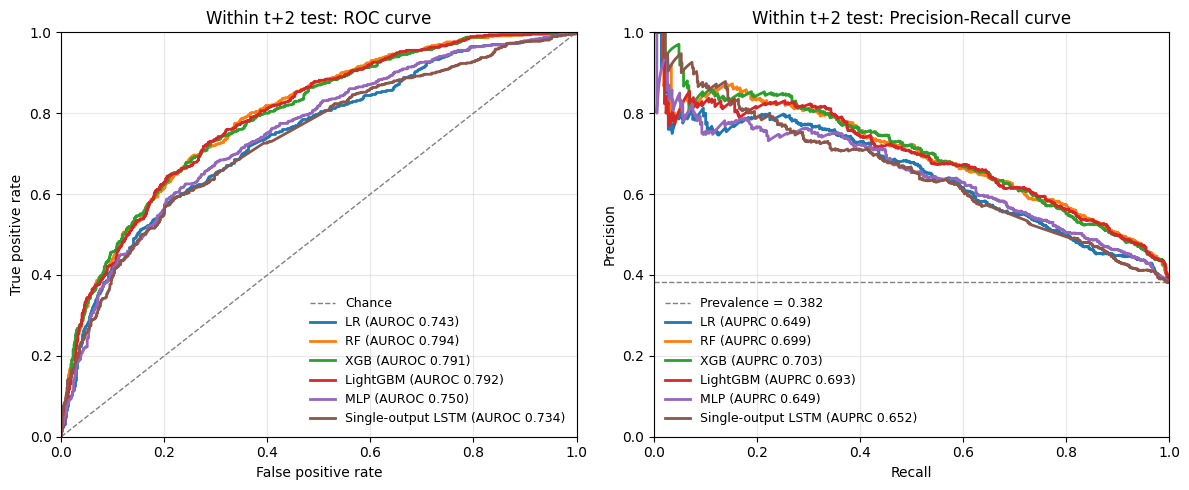

In [24]:
# Within t+2 모델별 기본 AUROC / AUPRC curve 시각화
def plot_roc_pr_curves(prediction_df: pd.DataFrame, target_col: str, model_prob_columns: dict[str, str], title_prefix: str, output_path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    y_true_all = prediction_df[target_col].astype(int)
    prevalence = y_true_all.mean()

    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Chance")
    axes[1].axhline(prevalence, linestyle="--", color="gray", linewidth=1, label=f"Prevalence = {prevalence:.3f}")

    for model, prob_col in model_prob_columns.items():
        curve_df = prediction_df[[target_col, prob_col]].dropna()
        if curve_df[target_col].nunique() < 2:
            continue

        y_true = curve_df[target_col].astype(int)
        y_prob = curve_df[prob_col].astype(float)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        auroc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)

        axes[0].plot(fpr, tpr, linewidth=2, label=f"{model} (AUROC {auroc:.3f})")
        axes[1].plot(recall, precision, linewidth=2, label=f"{model} (AUPRC {auprc:.3f})")

    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{title_prefix}: ROC curve")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)
    axes[0].legend(frameon=False, fontsize=9)

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix}: Precision-Recall curve")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)
    axes[1].legend(frameon=False, fontsize=9)

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_roc_pr_curves(
    within_predictions,
    target_col="y_within_t_plus_2_true",
    model_prob_columns=MODEL_PROB_COLUMNS,
    title_prefix="Within t+2 test",
    output_path=FIGURE_DIR / "within_t_plus_2_test_roc_pr_curves_by_model.png",
)



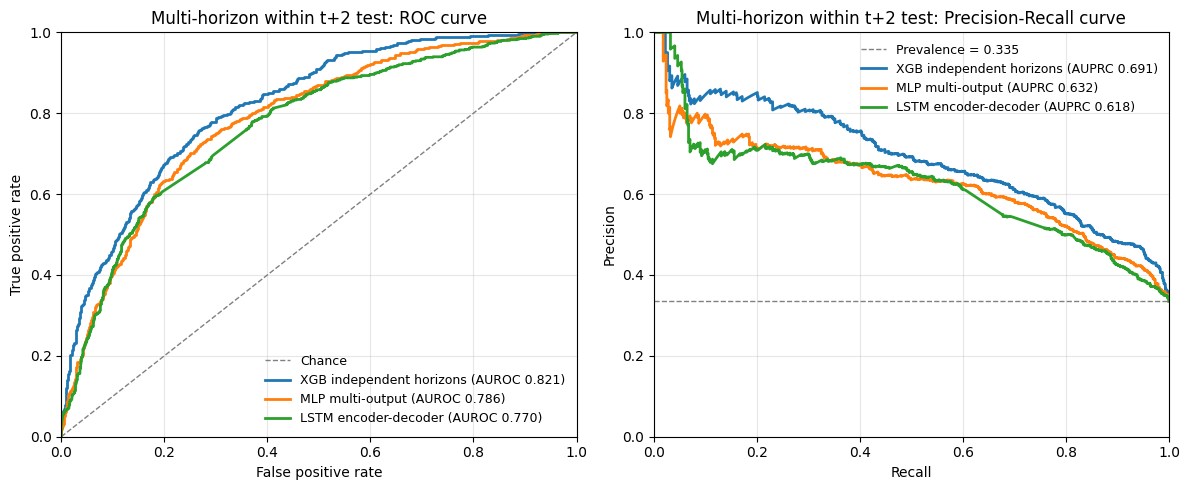

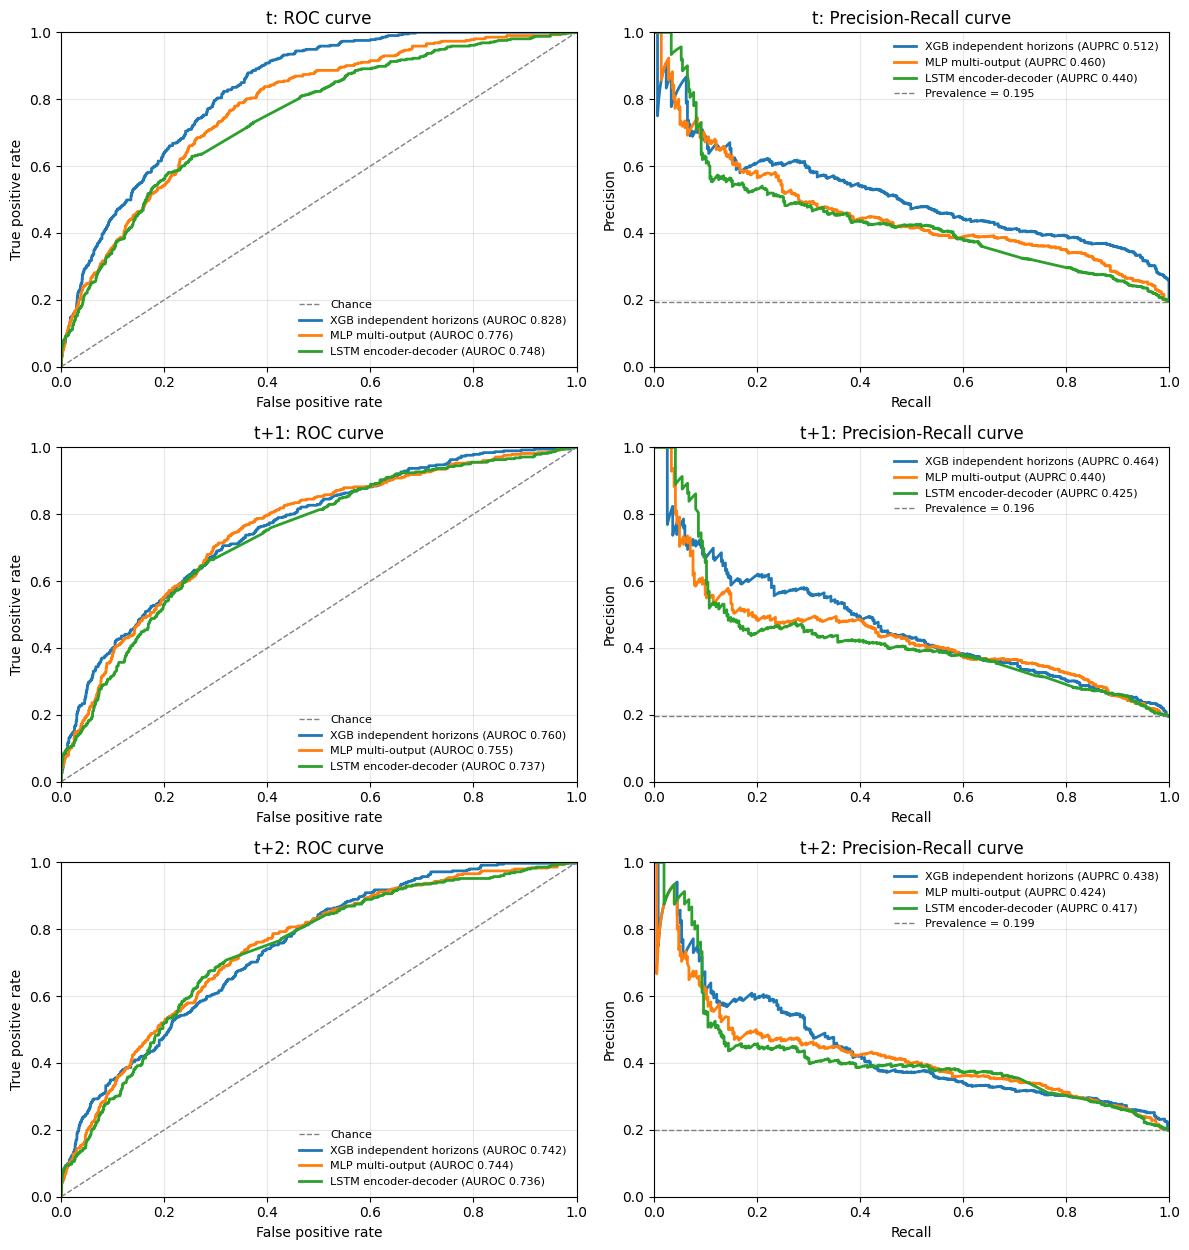

In [25]:
# Multi-horizon 모델별 기본 AUROC / AUPRC curve 시각화
multi_model_prediction_sets = [
    ("XGB independent horizons", xgb_multi_predictions),
    ("MLP multi-output", mlp_multi_predictions),
    ("LSTM encoder-decoder", multi_predictions),
]

multi_within_curve_df = pd.DataFrame(
    {
        "y_within_t_plus_2_true": xgb_multi_predictions["y_within_t_plus_2_true"].astype(int),
        "xgb_prob": xgb_multi_predictions["y_within_t_plus_2_prob_from_horizons"],
        "mlp_prob": mlp_multi_predictions["y_within_t_plus_2_prob_from_horizons"],
        "lstm_prob": multi_predictions["y_within_t_plus_2_prob_from_horizons"],
    }
)

plot_roc_pr_curves(
    multi_within_curve_df,
    target_col="y_within_t_plus_2_true",
    model_prob_columns={
        "XGB independent horizons": "xgb_prob",
        "MLP multi-output": "mlp_prob",
        "LSTM encoder-decoder": "lstm_prob",
    },
    title_prefix="Multi-horizon within t+2 test",
    output_path=FIGURE_DIR / "multi_horizon_within_t_plus_2_roc_pr_curves_by_model.png",
)


def plot_multi_horizon_roc_pr_by_horizon(prediction_sets: list[tuple[str, pd.DataFrame]], horizons: list[str], output_path: Path):
    fig, axes = plt.subplots(len(horizons), 2, figsize=(12, 4.2 * len(horizons)))
    if len(horizons) == 1:
        axes = np.array([axes])

    for row_idx, horizon in enumerate(horizons):
        true_col = f"{horizon}_true"
        prob_col = f"{horizon}_prob"
        mask_col = f"{horizon}_mask"
        roc_ax, pr_ax = axes[row_idx]

        roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Chance")

        prevalence_values = []
        for model, prediction_df in prediction_sets:
            curve_df = prediction_df.loc[prediction_df[mask_col].eq(1), [true_col, prob_col]].dropna()
            if curve_df[true_col].nunique() < 2:
                continue

            y_true = curve_df[true_col].astype(int)
            y_prob = curve_df[prob_col].astype(float)
            prevalence_values.append(y_true.mean())

            fpr, tpr, _ = roc_curve(y_true, y_prob)
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            auroc = roc_auc_score(y_true, y_prob)
            auprc = average_precision_score(y_true, y_prob)

            roc_ax.plot(fpr, tpr, linewidth=2, label=f"{model} (AUROC {auroc:.3f})")
            pr_ax.plot(recall, precision, linewidth=2, label=f"{model} (AUPRC {auprc:.3f})")

        if prevalence_values:
            pr_ax.axhline(np.mean(prevalence_values), linestyle="--", color="gray", linewidth=1, label=f"Prevalence = {np.mean(prevalence_values):.3f}")

        horizon_label = horizon.replace("y_", "").replace("_plus_", "+")
        roc_ax.set_title(f"{horizon_label}: ROC curve")
        roc_ax.set_xlabel("False positive rate")
        roc_ax.set_ylabel("True positive rate")
        roc_ax.set_xlim(0, 1)
        roc_ax.set_ylim(0, 1)
        roc_ax.grid(alpha=0.3)
        roc_ax.legend(frameon=False, fontsize=8)

        pr_ax.set_title(f"{horizon_label}: Precision-Recall curve")
        pr_ax.set_xlabel("Recall")
        pr_ax.set_ylabel("Precision")
        pr_ax.set_xlim(0, 1)
        pr_ax.set_ylim(0, 1)
        pr_ax.grid(alpha=0.3)
        pr_ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_multi_horizon_roc_pr_by_horizon(
    multi_model_prediction_sets,
    HORIZONS,
    output_path=FIGURE_DIR / "multi_horizon_test_horizon_roc_pr_curves_by_model.png",
)



## Previous delirium stratified evaluation

In [26]:
# binned modeling table의 anchor bin 기준 이전 delirium feature 결합
anchor_prev_delirium = (
    binned[["stay_id", "bin", "prev_delirium"]]
    .rename(columns={"bin": "anchor_bin"})
)


def attach_prev_delirium_group(prediction_df: pd.DataFrame) -> pd.DataFrame:
    prediction_df = prediction_df.merge(anchor_prev_delirium, on=["stay_id", "anchor_bin"], how="left")
    prediction_df["prev_delirium_group"] = np.where(
        prediction_df["prev_delirium"].astype(float) >= 0.5,
        "prev_delirium",
        "no_prev_delirium",
    )
    return prediction_df


PREV_DELIRIUM_ORDER = ["previous no delirium", "previous delirium"]
PREV_DELIRIUM_LABELS = {
    "previous_no_delirium": "previous no delirium",
    "previous_delirium": "previous delirium",
}


def sort_prev_delirium_table(table: pd.DataFrame, extra_sort_cols: list[str] | None = None) -> pd.DataFrame:
    table = table.copy()
    table["comparison"] = pd.Categorical(table["comparison"], categories=PREV_DELIRIUM_ORDER, ordered=True)
    sort_cols = ["comparison", *(extra_sort_cols or [])]
    table = table.sort_values(sort_cols).reset_index(drop=True)
    table["comparison"] = table["comparison"].astype(str)
    return table


def stratified_metric_table(metrics_df: pd.DataFrame, label_map: dict[str, str]) -> pd.DataFrame:
    table = metrics_df.copy()
    table["comparison"] = table["analysis"].map(label_map).fillna(table["analysis"])
    table = core_metric_table(table, leading_cols=["comparison", "model"], include_counts=True)
    table = table.rename(columns={"positive_rate": "Positive_rate"})
    table = table[["comparison", "model", "Positive_rate", "AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV"]]
    return sort_prev_delirium_table(table)


within_predictions = attach_prev_delirium_group(within_predictions)
xgb_multi_predictions = attach_prev_delirium_group(xgb_multi_predictions)
mlp_multi_predictions = attach_prev_delirium_group(mlp_multi_predictions)
multi_predictions = attach_prev_delirium_group(multi_predictions)


In [27]:
# XGB multi-horizon 모델의 previous delirium 기준 층화 평가
xgb_prev_within_rows = []
for analysis, subset in [
    ("previous_no_delirium", xgb_multi_predictions[xgb_multi_predictions["prev_delirium_group"] == "no_prev_delirium"]),
    ("previous_delirium", xgb_multi_predictions[xgb_multi_predictions["prev_delirium_group"] == "prev_delirium"]),
]:
    add_metric_row(
        xgb_prev_within_rows,
        analysis=analysis,
        model="XGB independent horizons",
        group=subset["prev_delirium_group"].iloc[0] if len(subset) else analysis,
        target="within_t_plus_2_delirium_from_horizons",
        y_true=subset["y_within_t_plus_2_true"],
        y_prob=subset["y_within_t_plus_2_prob_from_horizons"],
    )

xgb_prev_within_metrics = pd.DataFrame(xgb_prev_within_rows)
xgb_prev_within_metrics.to_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_prev_delirium_stratified_metrics.csv", index=False)
xgb_prev_within_display = stratified_metric_table(xgb_prev_within_metrics, PREV_DELIRIUM_LABELS)
display(round_float_columns(xgb_prev_within_display))

horizon_rows = []
for horizon in HORIZONS:
    true_col = f"{horizon}_true"
    mask_col = f"{horizon}_mask"
    prob_col = f"{horizon}_prob"
    for analysis, group_name in [
        ("previous_no_delirium", "no_prev_delirium"),
        ("previous_delirium", "prev_delirium"),
    ]:
        subset = xgb_multi_predictions[
            (xgb_multi_predictions["prev_delirium_group"] == group_name)
            & (xgb_multi_predictions[mask_col].eq(1))
        ]
        add_metric_row(
            horizon_rows,
            analysis=analysis,
            model="XGB independent horizons",
            group=group_name,
            target=f"{horizon}_delirium",
            y_true=subset[true_col],
            y_prob=subset[prob_col],
        )

xgb_prev_horizon_metrics = pd.DataFrame(horizon_rows)
xgb_prev_horizon_metrics.to_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_prev_delirium_horizon_metrics.csv", index=False)
xgb_prev_horizon_display = xgb_prev_horizon_metrics.copy()
xgb_prev_horizon_display["comparison"] = xgb_prev_horizon_display["analysis"].map(PREV_DELIRIUM_LABELS)
xgb_prev_horizon_display["horizon"] = (
    xgb_prev_horizon_display["target"]
    .str.replace("_delirium", "", regex=False)
    .map({"y_t": "t", "y_t_plus_1": "t+1", "y_t_plus_2": "t+2"})
)
xgb_prev_horizon_display = core_metric_table(
    xgb_prev_horizon_display,
    leading_cols=["comparison", "horizon"],
    include_counts=True,
).rename(columns={"positive_rate": "Positive_rate"})
xgb_prev_horizon_display = xgb_prev_horizon_display[
    ["comparison", "horizon", "Positive_rate", "AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "n"]
]
xgb_prev_horizon_display["horizon"] = pd.Categorical(xgb_prev_horizon_display["horizon"], categories=["t", "t+1", "t+2"], ordered=True)
xgb_prev_horizon_display = sort_prev_delirium_table(xgb_prev_horizon_display, extra_sort_cols=["horizon"])
display(round_float_columns(xgb_prev_horizon_display))


,comparison,model,Positive_rate,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV
0,previous no delirium,XGB independent horizons,0.248,0.777,0.493,0.960,0.370,0.335,0.966
1,previous delirium,XGB independent horizons,0.704,0.712,0.835,0.996,0.092,0.723,0.917


,comparison,horizon,Positive_rate,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,n
0,previous no delirium,t,0.128,0.807,0.320,0.800,0.696,0.279,0.959,1716
1,previous no delirium,t+1,0.133,0.690,0.230,0.534,0.731,0.234,0.911,1561
2,previous no delirium,t+2,0.136,0.688,0.219,0.618,0.648,0.217,0.915,1404
3,previous delirium,t,0.477,0.659,0.632,0.969,0.170,0.515,0.857,405
4,previous delirium,t+1,0.452,0.661,0.622,0.983,0.062,0.463,0.812,383
5,previous delirium,t+2,0.444,0.636,0.604,0.925,0.119,0.456,0.667,363


## Save augmented prediction tables

In [30]:
# previous delirium 상태가 결합된 row-level prediction table 저장
within_predictions.to_csv(MODELING_OUTPUT_DIR / "within_t_plus_2_test_predictions_all_models_with_prev_delirium.csv", index=False)
xgb_multi_predictions.to_csv(MODELING_OUTPUT_DIR / "xgb_multi_horizon_test_predictions_with_prev_delirium.csv", index=False)
mlp_multi_predictions.to_csv(MODELING_OUTPUT_DIR / "mlp_multi_horizon_test_predictions_with_prev_delirium.csv", index=False)
multi_predictions.to_csv(MODELING_OUTPUT_DIR / "lstm_gpu_test_predictions_with_prev_delirium.csv", index=False)

# 핵심 결과만 별도 폴더에 저장
key_result_paths = [
    save_key_result(within_core_metrics, "within_t_plus_2_core_test_metrics.csv"),
    save_key_result(multi_core_metrics, "multi_horizon_core_test_metrics.csv"),
    save_key_result(xgb_prev_within_display, "xgb_prev_delirium_within_t_plus_2_metrics.csv"),
    save_key_result(xgb_prev_horizon_display, "xgb_prev_delirium_horizon_metrics.csv"),
]

best_within = within_core_metrics.sort_values("AUPRC", ascending=False).iloc[0]
best_multi_t2 = multi_core_metrics[multi_core_metrics["horizon"].eq("t+2")].sort_values("AUPRC", ascending=False).iloc[0]
summary_lines = [
    "# Key result summary",
    "",
    f"Best within t+2 model by AUPRC: {best_within['model']} "
    f"(AUROC {best_within['AUROC']:.3f}, AUPRC {best_within['AUPRC']:.3f})",
    f"Best multi-horizon model at t+2 by AUPRC: {best_multi_t2['model']} "
    f"(AUROC {best_multi_t2['AUROC']:.3f}, AUPRC {best_multi_t2['AUPRC']:.3f})",
    "",
    "Saved files:",
    *[f"- {path.name}" for path in key_result_paths],
]
(RESULT_ANALYSIS_DIR / "key_result_summary.md").write_text("\n".join(summary_lines), encoding="utf-8")

print("Saved augmented prediction tables to", MODELING_OUTPUT_DIR)
print("Saved key result files to", RESULT_ANALYSIS_DIR)


Saved augmented prediction tables to /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/modeling
Saved key result files to /Users/oneash/ONEASH_local/Coding/Delirium-Prediction/Parkinson/outputs/result_analysis
